# Accessibility Scores
### This notebook contains a focused example of using accessX to estimate accessibility scores for Amsterdam, Athens, and Milan.

The workflow prepares the inputs needed for accessibility analysis and calculates four complementary measures:

- reachable POI counts within a travel-time threshold
- travel cost to the nearest POI by category
- Hansen distance-decay accessibility
- two-step floating catchment area (2SFCA) accessibility

This notebook does not include equity analysis or isochrones.

In [1]:
from pathlib import Path

import accessx as acx
import matplotlib.pyplot as plt
import osmnx as ox
import pandas as pd

## Setup

In [6]:
epsg_ams = 28992
epsg_ath = 2100
epsg_mil = 32632

resolution = 9
worldpop_year = 2020
network_buffer_m = 1000
poi_buffer_m = 500
walking_speed_kmh = 4.5
cost_attr = "avg_time"
max_cost = 15
max_distance_from_graph = 200.0

data_path = Path("../data/case_studies/accessibility")
area_path = data_path / "area"
population_path = data_path / "population"
pois_path = data_path / "pois"
street_network_path = data_path / "street_network"
results_path = data_path / "results"

for folder in [data_path, area_path, population_path, pois_path, street_network_path, results_path]:
    folder.mkdir(parents=True, exist_ok=True)

city_data = [
    {"name": "amsterdam", "label": "Amsterdam", "epsg": epsg_ams},
    {"name": "athens", "label": "Athens", "epsg": epsg_ath},
    {"name": "milan", "label": "Milan", "epsg": epsg_mil},
]

## Load Areas of Interest

In [3]:
aois = {
    "amsterdam": ox.geocode_to_gdf("Amsterdam, Netherlands"),
    "athens": ox.geocode_to_gdf("Municipality of Athens, Greece"),
    "milan": ox.geocode_to_gdf("Milan, Italy"),
}

for city in city_data:
    acx.save_gdf(aois[city["name"]], area_path / f"aoi_{city['name']}.geojson")

# Uncomment to read saved AOIs instead of geocoding.
# aois = {
#     city["name"]: acx.read_gdf(area_path / f"aoi_{city['name']}.geojson")
#     for city in city_data
# }

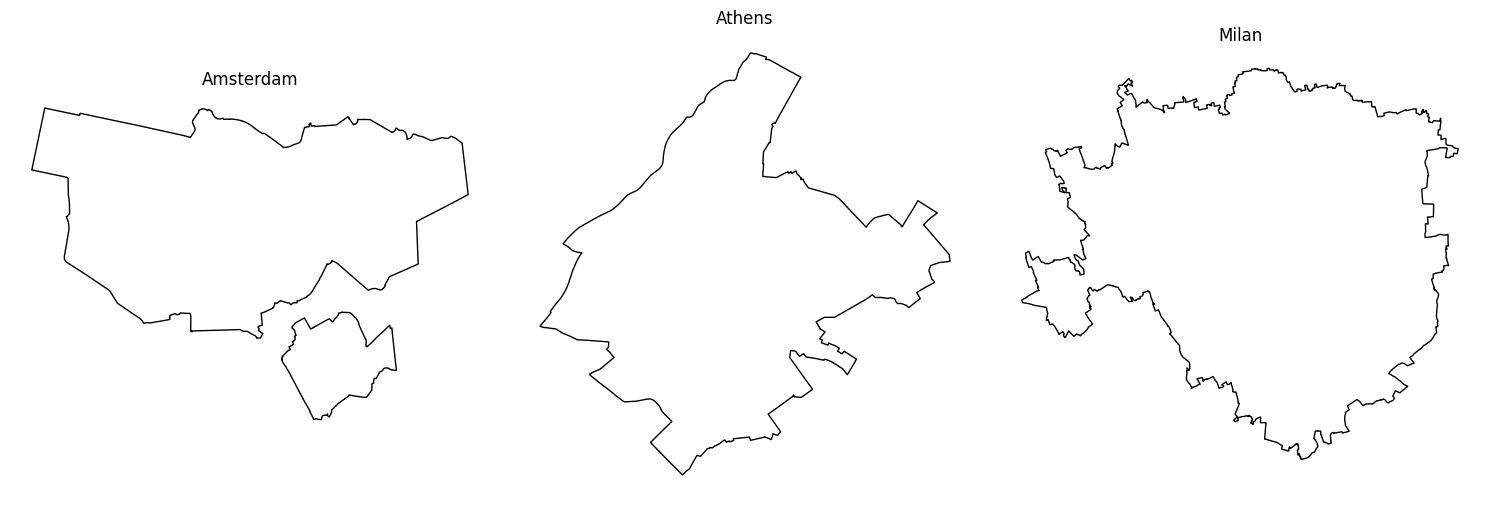

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, city in zip(axes, city_data):
    aois[city["name"]].plot(ax=ax, facecolor="none", edgecolor="black")
    ax.set_title(city["label"])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Make Hex Grids

Hexagons are the origins for the accessibility calculations.

In [5]:
hexes = {}

for city in city_data:
    name = city["name"]
    hexes[name] = acx.make_hex_grid(aoi=aois[name], resolution=resolution)
    acx.save_gdf(hexes[name], area_path / f"hexes_{name}.geojson")

# Uncomment to read saved hex grids instead of recomputing.
# hexes = {
#     city["name"]: acx.read_gdf(area_path / f"hexes_{city['name']}.geojson")
#     for city in city_data
# }

## Prepare Walking Networks and Travel-Time Costs

The network is downloaded with a buffer so origins near the municipal boundary can still reach destinations just outside it. A constant walking speed is converted into the edge cost column used by all routing-based accessibility functions.

In [ ]:
graphs = {}

for city in city_data:
    name = city["name"]
    epsg = city["epsg"]

    graph = acx.build_network(
        AOI=aois[name],
        city_epsg=epsg,
        buffer_m=network_buffer_m,
        network_type="walk",
        simplify=False,
        retain_all=True,
    )
    graph = acx.add_time_cost_constant_speed(
        graph,
        speed_kmh=walking_speed_kmh,
        cost_col=cost_attr,
    )
    graphs[name] = graph

    acx.save_graph(
        graph,
        out_dir=street_network_path,
        base_name=f"{name}_graph_with_cost",
    )

# Uncomment to read saved networks instead of downloading them again.
# graphs = {
#     city["name"]: acx.load_graph(
#         out_dir=street_network_path,
#         base_name=f"{city['name']}_graph_with_cost",
#         crs=city["epsg"],
#     )
#     for city in city_data
# }

## Collect POIs

`poi_groups` defines analytical categories for accessibility while preserving the original OSM key and value in the POI output.

In [ ]:
poi_groups = {
    "healthcare": {
        "amenity": ["pharmacy", "clinic", "doctors", "dentist", "hospital"],
        "healthcare": True,
    },
    "education": {
        "amenity": ["kindergarten", "childcare", "school", "college", "university", "library"],
    },
    "daily_needs": {
        "shop": ["supermarket", "convenience", "greengrocer", "bakery", "butcher", "chemist"],
        "amenity": ["marketplace", "post_office", "bank", "atm"],
    },
    "open_space_and_play": {
        "leisure": ["park", "playground", "garden", "dog_park", "recreation_ground"],
    },
    "public_transport": {
        "highway": ["bus_stop"],
        "railway": ["station", "halt", "tram_stop", "subway_entrance"],
        "public_transport": ["platform", "stop_position", "station"],
    },
}

pois = {}
poi_reports = {}

for city in city_data:
    name = city["name"]
    epsg = city["epsg"]
    pois[name], poi_reports[name] = acx.get_pois_osm(
        aois[name],
        city_epsg=epsg,
        buffer_m=poi_buffer_m,
        poi_groups=poi_groups,
        max_retries=4,
        show_progress=True,
        return_report=True,
        columns=["amenity", "shop", "leisure", "highway", "railway", "public_transport", "healthcare"],
    )
    # A feature can match more than one OSM query inside the same custom group.
    # Keep one opportunity per category and OSM identity before calculating scores.
    pois[name] = pois[name].drop_duplicates(
        subset=["category", "osm_type", "osmid"]
    ).reset_index(drop=True)
    pois[name]["id"] = range(len(pois[name]))

    acx.save_gdf(pois[name], pois_path / f"pois_{name}.geojson")

# Uncomment to read saved POIs instead of querying OSM again.
# pois = {
#     city["name"]: acx.read_gdf(pois_path / f"pois_{city['name']}.geojson")
#     for city in city_data
# }

In [10]:
poi_summary = []
for city in city_data:
    name = city["name"]
    counts = pois[name].groupby("category").size().rename("pois").reset_index()
    counts.insert(0, "city", city["label"])
    poi_summary.append(counts)

pd.concat(poi_summary, ignore_index=True)

,city,category,pois
0,Amsterdam,daily_needs,1301
1,Amsterdam,education,590
2,Amsterdam,healthcare,514
3,Amsterdam,open_space_and_play,8311
4,Amsterdam,public_transport,3252
5,Athens,daily_needs,1805
6,Athens,education,387
7,Athens,healthcare,864
8,Athens,open_space_and_play,720
9,Athens,public_transport,2041


## 1. Cumulative Opportunity Measure

The cumulative opportunity measure counts how many destinations in each POI category can be reached from each hex within `max_cost` minutes.

In [12]:
accessible_counts = {}

for city in city_data:
    name = city["name"]
    epsg = city["epsg"]

    accessible_counts[name] = acx.count_accessible_pois(
        graphs[name],
        hexes[name].to_crs(epsg),
        pois[name].to_crs(epsg),
        max_cost=max_cost,
        cost_attr=cost_attr,
        id_col="hex_id",
        category_col="category",
        max_distance_from_graph=max_distance_from_graph,
        show_progress=True,
    )
    acx.save_gdf(accessible_counts[name], results_path / f"accessible_counts_{name}.geojson")

Counting accessible POIs:   0%|          | 0/2477 [00:00<?, ?hex/s]

Counting accessible POIs:   0%|          | 0/309 [00:00<?, ?hex/s]

Counting accessible POIs:   0%|          | 0/1743 [00:00<?, ?hex/s]

### Visual - Cumulative Opportunity Measure

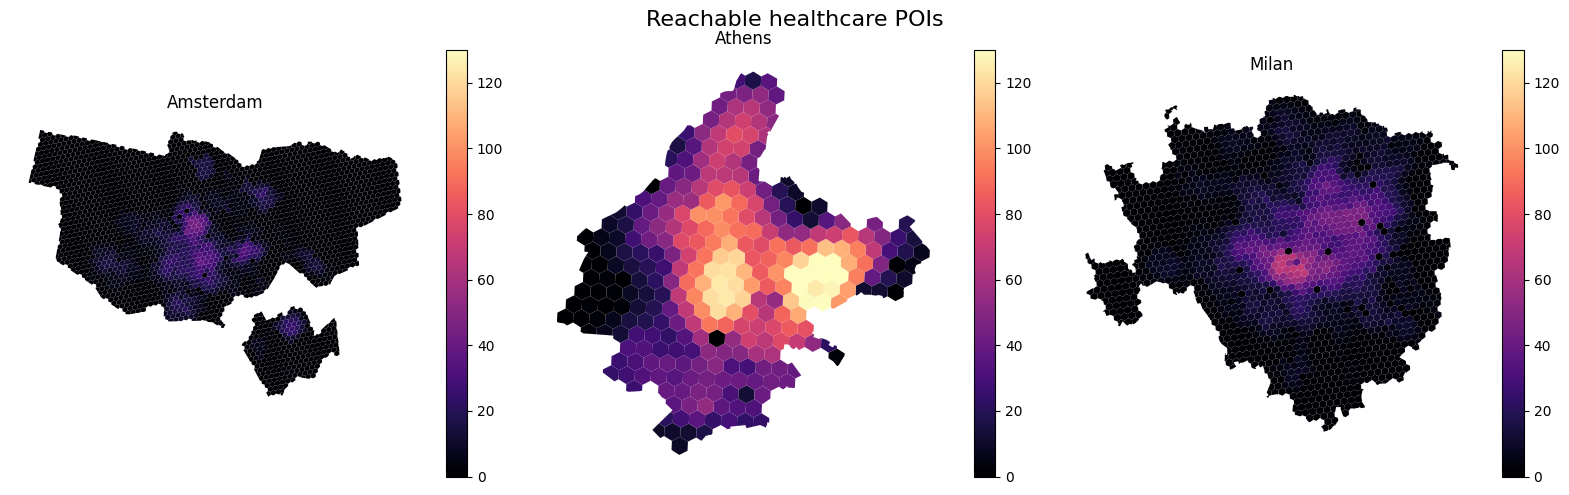

In [22]:
category = "healthcare"
metric = f"count_{category}"
cities = ['amsterdam', 'athens', 'milan']
fig, axes = plt.subplots(1, len(cities), figsize=(16, 5))

vmin = min(accessible_counts[city][metric].quantile(0.02) for city in cities)
vmax = max(accessible_counts[city][metric].quantile(0.98) for city in cities)

for ax, city in zip(axes, cities):
    accessible_counts[city].plot(
        column=metric,
        ax=ax,
        legend=True,
        cmap="magma",
        vmin=vmin,
        vmax=vmax,
        edgecolor="none",
        missing_kwds={"color": "lightgrey"},
    )

    ax.set_title(city.title())
    ax.axis("off")

fig.suptitle("Cumulative healthcare opportunities", fontsize=16)
plt.tight_layout()
plt.show()

## 2. Nearest POI Cost

Nearest POI cost measures the shortest network travel cost to the nearest reachable destination in each category. The wide output is convenient for mapping and tabular analysis.

In [13]:
nearest_poi_costs = {}

for city in city_data:
    name = city["name"]
    epsg = city["epsg"]

    nearest_poi_costs[name] = acx.compute_nearest_poi_cost(
        graphs[name],
        hexes[name].to_crs(epsg),
        pois[name].to_crs(epsg),
        max_cost=max_cost,
        cost_attr=cost_attr,
        id_col="hex_id",
        category_col="category",
        poi_id_col="id",
        max_distance_from_graph=max_distance_from_graph,
        number_of_nearest=1,
        output="wide",
        show_progress=True,
    )
    acx.save_gdf(nearest_poi_costs[name], results_path / f"nearest_poi_costs_{name}.geojson")

Computing nearest POIs:   0%|          | 0/2477 [00:00<?, ?hex/s]

Computing nearest POIs:   0%|          | 0/309 [00:00<?, ?hex/s]

Computing nearest POIs:   0%|          | 0/1743 [00:00<?, ?hex/s]

### Visual Nearest POIs

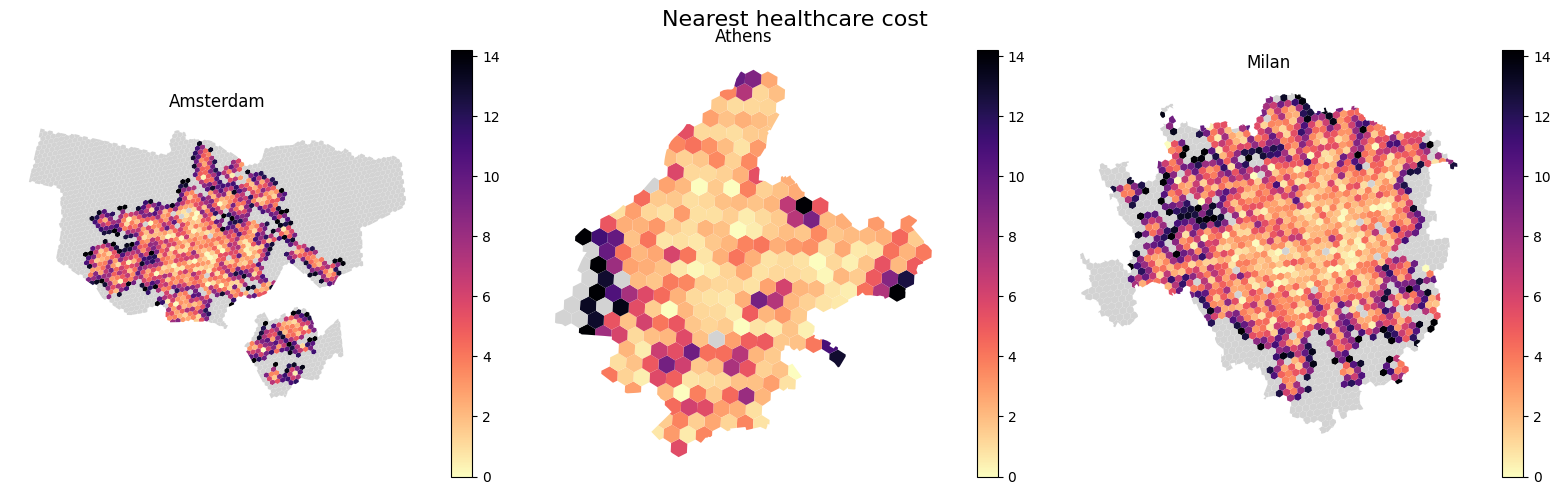

In [24]:
category = "healthcare"
metric = f"nearest_cost_{category}_1"

fig, axes = plt.subplots(1, len(cities), figsize=(16, 5))

vmin = min(nearest_poi_costs[city][metric].quantile(0.02) for city in cities)
vmax = max(nearest_poi_costs[city][metric].quantile(0.98) for city in cities)

for ax, city in zip(axes, cities):
    nearest_poi_costs[city].plot(
        column=metric,
        ax=ax,
        legend=True,
        cmap="magma_r",  # reversed because lower cost is better
        vmin=vmin,
        vmax=vmax,
        edgecolor="none",
        missing_kwds={"color": "lightgrey"},
    )

    ax.set_title(city.title())
    ax.axis("off")

fig.suptitle("Nearest healthcare cost", fontsize=16)
plt.tight_layout()
plt.show()

## 3. Hansen Accessibility

Hansen accessibility sums reachable opportunities while applying exponential distance decay. Nearby POIs contribute more than POIs close to the travel-time threshold.

In [14]:
hansen_scores = {}

for city in city_data:
    name = city["name"]
    epsg = city["epsg"]

    hansen_scores[name] = acx.compute_hansen_accessibility(
        graph=graphs[name],
        hexes=hexes[name].to_crs(epsg),
        pois=pois[name].to_crs(epsg),
        max_cost=max_cost,
        cost_attr=cost_attr,
        id_col="hex_id",
        category_col="category",
        default_poi_weight=1.0,
        beta=0.15,
        max_distance_from_graph=max_distance_from_graph,
        show_progress=True,
    )
    acx.save_gdf(hansen_scores[name], results_path / f"hansen_accessibility_{name}.geojson")

Computing Hansen accessibility:   0%|          | 0/2477 [00:00<?, ?hex/s]

Computing Hansen accessibility:   0%|          | 0/309 [00:00<?, ?hex/s]

Computing Hansen accessibility:   0%|          | 0/1743 [00:00<?, ?hex/s]

### Visual Hansen

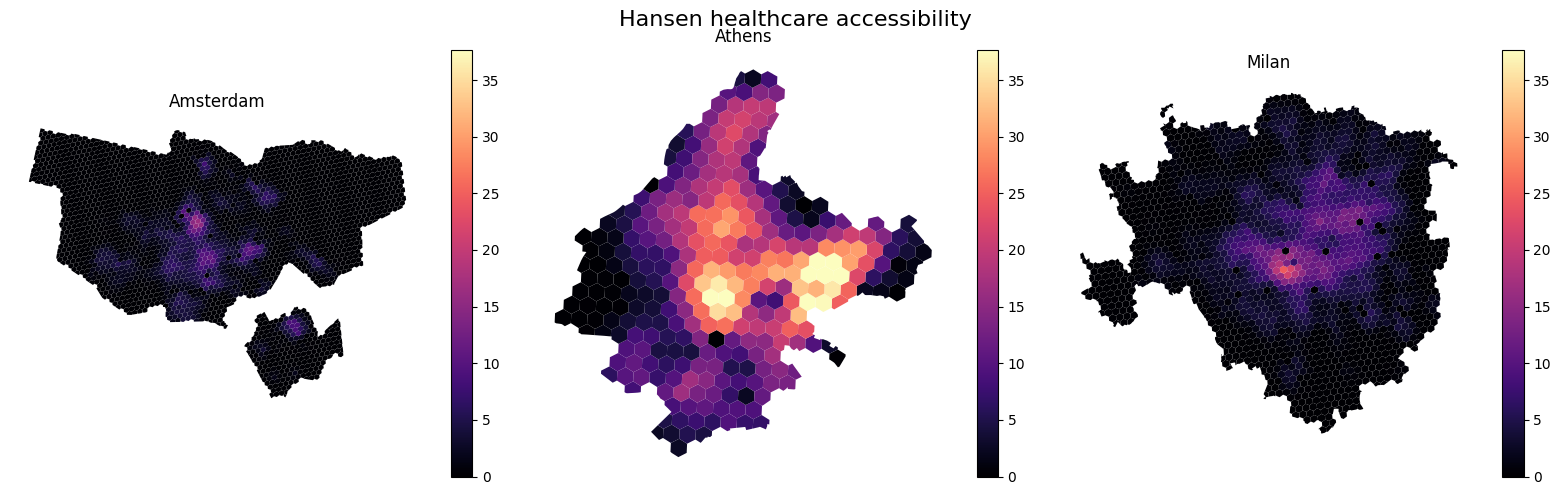

In [26]:
category = "healthcare"
metric = f"hansen_{category}"

fig, axes = plt.subplots(1, len(cities), figsize=(16, 5))

vmin = min(hansen_scores[city][metric].quantile(0.02) for city in cities)
vmax = max(hansen_scores[city][metric].quantile(0.98) for city in cities)

for ax, city in zip(axes, cities):
    hansen_scores[city].plot(
        column=metric,
        ax=ax,
        legend=True,
        cmap="magma",
        vmin=vmin,
        vmax=vmax,
        edgecolor="none",
        missing_kwds={"color": "lightgrey"},
    )

    ax.set_title(city.title())
    ax.axis("off")

fig.suptitle("Hansen healthcare accessibility", fontsize=16)
plt.tight_layout()
plt.show()

## 4. Two-Step Floating Catchment Area Accessibility

2SFCA combines POI supply with population demand. With no explicit capacity column, each POI contributes the same default supply. The exponential decay option produces an E2SFCA-like measure.

## Prepare Population Demand for 2SFCA

Only 2SFCA requires population demand. The other accessibility measures can be calculated directly from hexagons, POIs, and the walking network.

In [15]:
# worldpop_rasters = {}
# hexes_with_population = {}

# for city in city_data:
#     name = city["name"]
#     raster_path = population_path / f"{name}_worldpop_{worldpop_year}.tif"

#     worldpop_rasters[name] = acx.get_worldpop_raster(
#         aoi=aois[name],
#         year=worldpop_year,
#         clip=True,
#         save_path=raster_path,
#     )
#     hexes_with_population[name] = acx.map_population_to_hexes(
#         hexes[name],
#         worldpop_rasters[name],
#         metric_crs=city["epsg"],
#     )
#     acx.save_gdf(
#         hexes_with_population[name],
#         population_path / f"hexes_population_{name}.geojson",
#     )

# Uncomment to read saved population hexes instead of downloading and mapping again.
hexes_with_population = {
    city["name"]: acx.read_gdf(population_path / f"hexes_population_{city['name']}.geojson")
    for city in city_data
}

In [16]:
sfca_scores = {}

for city in city_data:
    name = city["name"]
    epsg = city["epsg"]

    sfca_scores[name] = acx.compute_2sfca_accessibility(
        graph=graphs[name],
        hexes=hexes_with_population[name].to_crs(epsg),
        pois=pois[name].to_crs(epsg),
        max_cost=max_cost,
        cost_attr=cost_attr,
        demand_col="population",
        id_col="hex_id",
        category_col="category",
        supply_col=None,
        default_supply=1.0,
        max_distance_from_graph=max_distance_from_graph,
        decay="exp",
        beta=0.15,
        show_progress=True,
    )
    acx.save_gdf(sfca_scores[name], results_path / f"sfca_accessibility_{name}.geojson")

Computing 2SFCA provider catchments:   0%|          | 0/10068 [00:00<?, ?node/s]

Computing 2SFCA demand catchments:   0%|          | 0/2477 [00:00<?, ?hex/s]

Computing 2SFCA provider catchments:   0%|          | 0/4143 [00:00<?, ?node/s]

Computing 2SFCA demand catchments:   0%|          | 0/309 [00:00<?, ?hex/s]

Computing 2SFCA provider catchments:   0%|          | 0/11252 [00:00<?, ?node/s]

Computing 2SFCA demand catchments:   0%|          | 0/1743 [00:00<?, ?hex/s]

### Visual 2SFCA

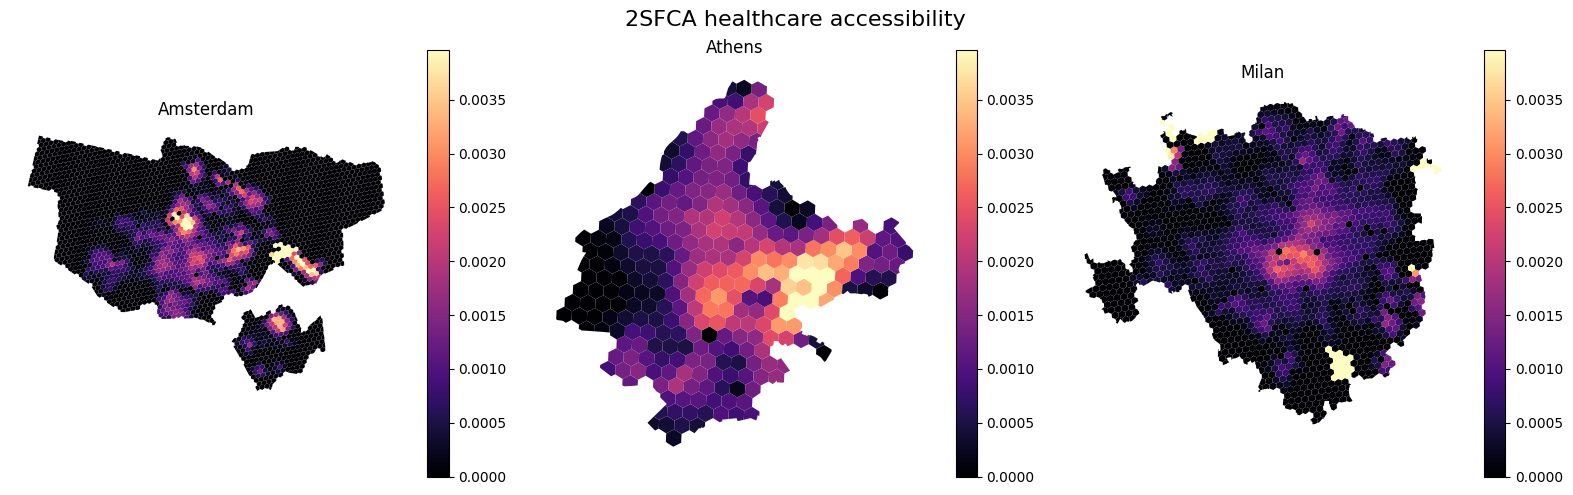

In [29]:
category = "healthcare"
metric = f"sfca_{category}"

fig, axes = plt.subplots(1, len(cities), figsize=(16, 5))

vmin = min(sfca_scores[city][metric].quantile(0.02) for city in cities)
vmax = max(sfca_scores[city][metric].quantile(0.98) for city in cities)

for ax, city in zip(axes, cities):
    sfca_scores[city].plot(
        column=metric,
        ax=ax,
        legend=True,
        cmap="magma",
        vmin=vmin,
        vmax=vmax,
        edgecolor="none",
        missing_kwds={"color": "lightgrey"},
    )

    ax.set_title(city.title())
    ax.axis("off")

fig.suptitle("2SFCA healthcare accessibility", fontsize=16)
plt.tight_layout()
plt.show()

## Compare Accessibility Outputs

Each function returns one row per hex. The column prefixes identify the measure:

- `count_`: reachable POI counts
- `nearest_cost_`: nearest POI travel cost
- `hansen_`: Hansen accessibility
- `sfca_`: 2SFCA accessibility

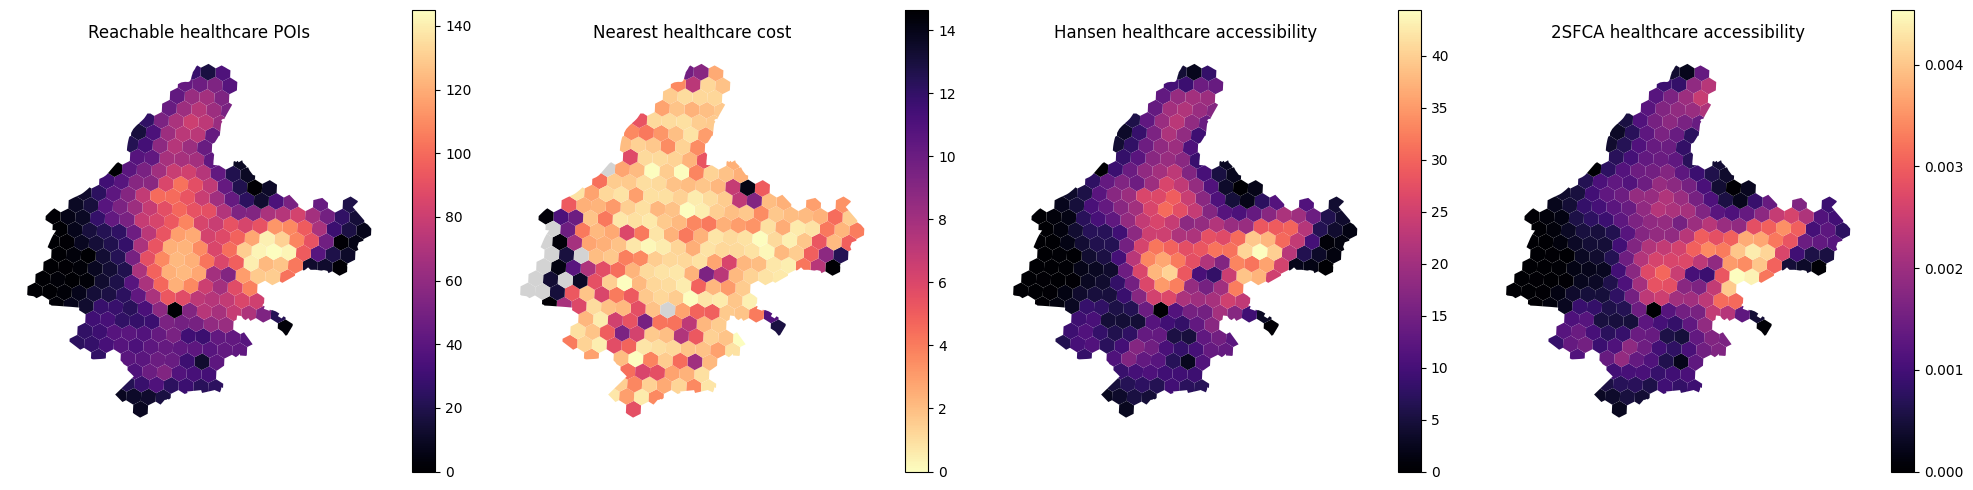

In [30]:
metrics = [
    "count_healthcare",
    "nearest_cost_healthcare_1",
    "hansen_healthcare",
    "sfca_healthcare",
]

titles = [
    "Cumulative healthcare opportunities",
    "Nearest healthcare cost",
    "Hansen healthcare accessibility",
    "2SFCA healthcare accessibility",
]

cmaps = [
    "magma",
    "magma_r",  # lower nearest cost is better
    "magma",
    "magma",
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, metric, title, cmap in zip(axes, metrics, titles, cmaps):
    comparison.plot(
        column=metric,
        ax=ax,
        legend=True,
        cmap=cmap,
        edgecolor="none",
        missing_kwds={"color": "lightgrey"},
    )

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Saved Outputs

The `results` folder contains separate GeoJSON files for each accessibility measure and city. These outputs can be used directly in later mapping and statistical analysis.